# Inequality in Educational Opportunity - Data Analysis and Modeling

In this notebook, we will analyze the prepared education dataset to explore inequality in educational opportunities across different socioeconomic factors. We will perform exploratory data analysis (EDA), visualize trends, and build predictive model, to understand the impact of various factors on high school student performance. Then we will add additional variables to improve model performance.

## Project Overview

This project addresses inequality of educational opportunity in U.S. high schools. Here we will focus on average student performance on the ACT or SAT exams that students take as part of the college application process.

We expect a range of school performance on these exams, but is school performance associated with socioeconomic factors?

Can school performance be predicted based on socioeconomic factors?

## Data Sources

### School Performance Data
The primary data source is the [EdGap.org](https://edgap.org/) dataset, which compiles high school performance data on the ACT and SAT exams along with socioeconomic indicators for each school. 

### School Information Data
The school information data is from the [National Center for Education Statistics](https://nces.ed.gov/ccd/pubschuniv.asp). This data set consists of basic identifying information about schools including location, type of school, and enrollment.

### School District Financial Data (additional predictor data source)
The school financial data is from the [National Center for Education Statistics](https://nces.ed.gov/ccd/data_slfs.asp). This dataset includes information on district level funding, expenditures, and financial resources.

## Project Overview

This project addresses inequality of educational opportunity in U.S. high schools. Here we will focus on average student performance on the ACT or SAT exams that students take as part of the college application process.

We expect a range of school performance on these exams, but is school performance associated with socioeconomic factors?

In this notebook, we will prepare a dataset for analysis and visualization. We will combine data from 2 sources, clean the data, and perform imputation where necessary.

# Import libraries

We will import the necessary libraries for data analysis, visualization, and modeling.

In [486]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is a data visualization library built on matplotlib
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")
sns.set_palette('deep')

# Model preprocessing
from sklearn.preprocessing import StandardScaler

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm

## Load the data

Load the prepared education dataset for analysis.

In [487]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/JLichwa80/education/refs/heads/master/data/education_data_cleaned.csv'
)

In [488]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7227 entries, 0 to 7226
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              7227 non-null   int64  
 1   rate_unemployment               7227 non-null   float64
 2   percent_college                 7227 non-null   float64
 3   percent_married                 7227 non-null   float64
 4   median_income                   7227 non-null   float64
 5   average_act                     7227 non-null   float64
 6   percent_lunch                   7227 non-null   float64
 7   year                            7227 non-null   object 
 8   state                           7227 non-null   object 
 9   zip_code                        7227 non-null   int64  
 10  school_type                     7227 non-null   object 
 11  school_level                    7227 non-null   object 
 12  charter                         72

In [489]:
df.head()

,id,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,year,state,zip_code,school_type,school_level,charter,instr_expenditures_per_student,total_expenditures_per_student
0,100001600143,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,2016-2017,DE,19804,Regular School,High,Yes,738.013699,11077.054795
1,100008000024,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,2016-2017,DE,19709,Regular School,High,No,7856.069147,13089.158211
2,100008000225,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,2016-2017,DE,19709,Regular School,High,No,7856.069147,13089.158211
3,100017000029,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,2016-2017,DE,19958,Regular School,High,No,9141.933029,27295.471842
4,100018000040,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,2016-2017,DE,19934,Regular School,High,No,9351.625488,16028.608583


# Exploratory data analysis

Explore the dataset to understand the distribution of variables, identify patterns, and visualize relationships between socioeconomic factors and student performance.

### Examine distributions and relationships



We will plot the correlation matrix of the numerical variables in the training data to explore relationships between the variables.

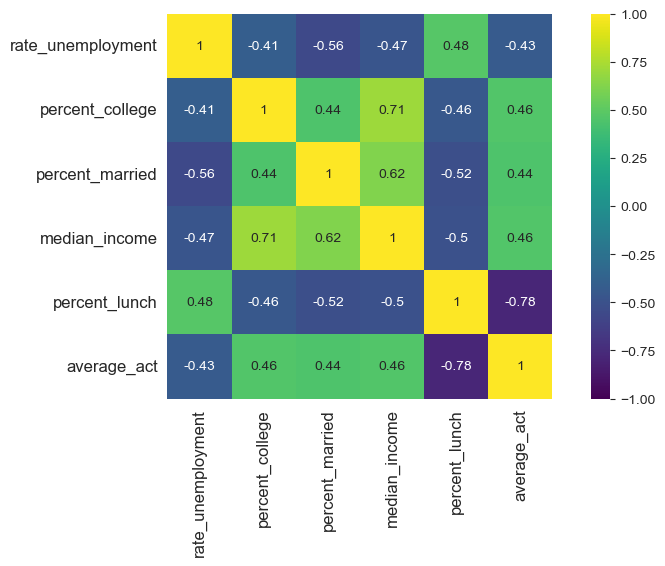

In [490]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_married', 'median_income', 'percent_lunch', 'state', 'charter']

numerical_predictors = df[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df[numerical_predictors + ["average_act"]].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

We can see that the strongest correlations with ACT/SAT scores is percent of free lunch, similar like we identified during data preparation. Other factors show moderate correlations, indicating multiple influences on student performance.

Next we will show pair plots to explore relationships between the variables. We will differentiate regression lines by charter school status to see if there are differences in trends.

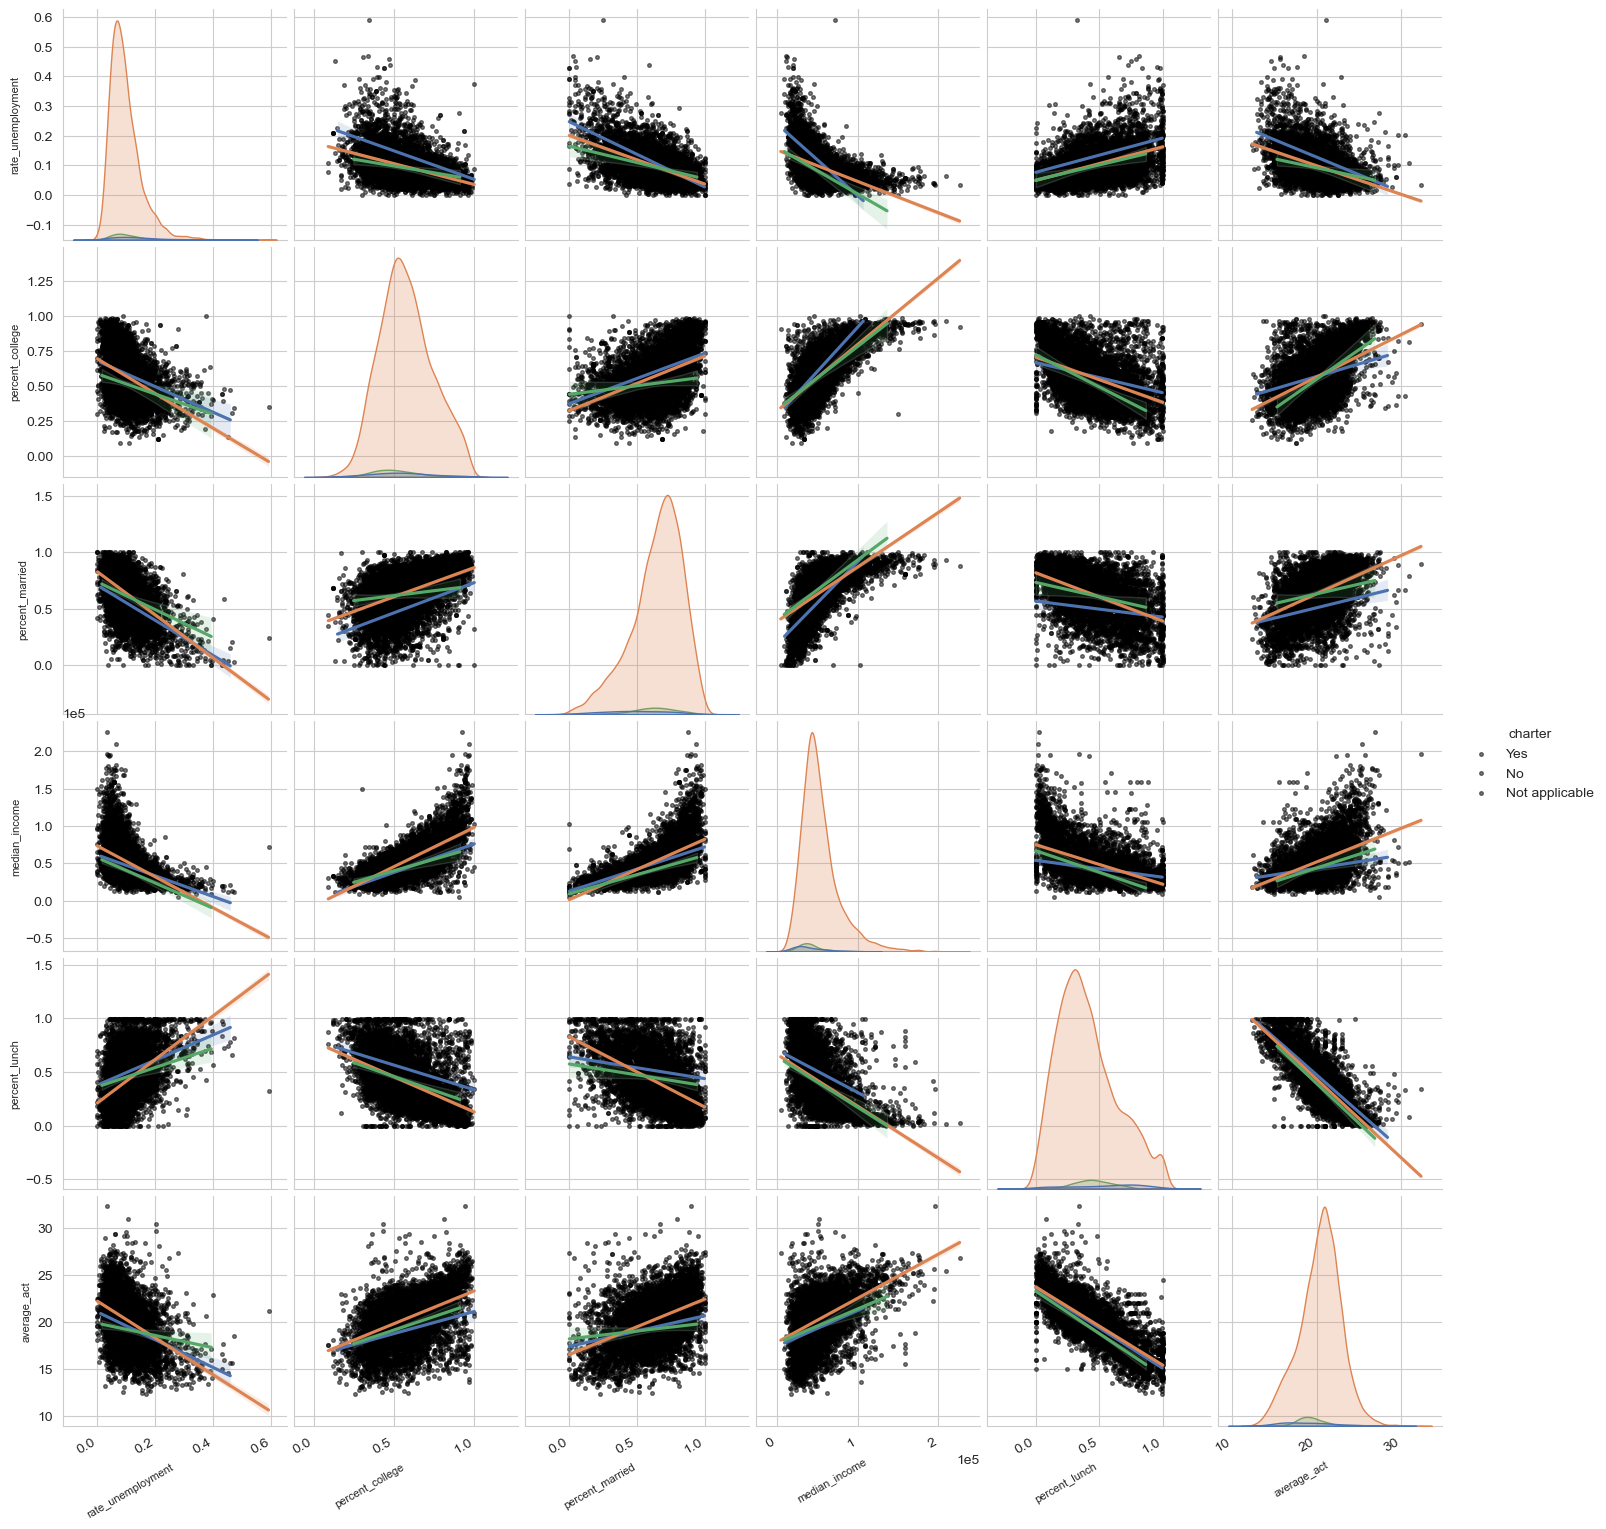

In [491]:
fig = sns.pairplot(
    data=df,
    vars=numerical_predictors + ['average_act'],
    hue='charter',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)

for ax in fig.axes.flat:
    if ax.get_xlabel() == 'median_income':
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))  # Apply scientific notation
    if ax.get_ylabel() == 'median_income':
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))  # Apply scientific notation
    ax.set_xlabel(ax.get_xlabel(), fontsize=8, rotation=30, ha='right')  # X-axis label size and rotation
    ax.set_ylabel(ax.get_ylabel(), fontsize=8)  # Y-axis label size

    # Rotate x-axis tick labels
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.show()

We can notice small differences in trends between charter and non-charter schools, but overall the relationships are similar. We can also see correlation between predictor variables, such as median income and percent of free lunch which means that not all predictors will be required in the model. Distributions plots show that some variables have skewed distributions, which may require transformation for modeling.

### Identify outliers

We can use the interquartile range to identify outliers. Outliers can have a significant impact on regression models, so we will need to consider how to handle them.

#### Numerical predictors minus median income boxplots

We will first look at rate of unemployment, percent of free lunch, percent of college, and percent of married predictors, and analyze median income separately due to its different scale.

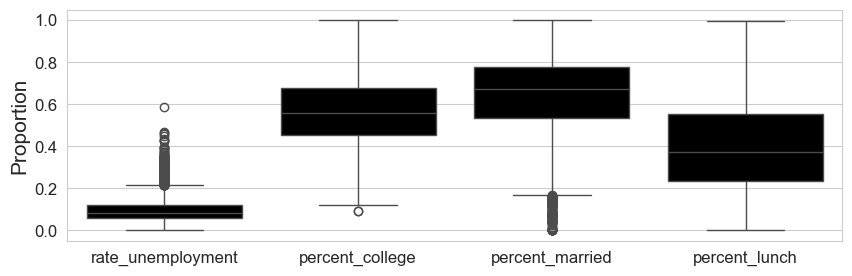

In [492]:
plt.figure(figsize=(10,3))

fractions = list(numerical_predictors)
fractions.remove('median_income')

sns.boxplot(data=df[fractions], color='k')

plt.ylabel('Proportion', fontsize=15)

plt.tick_params(labelsize=12)

plt.show()

From above plot we can notice most outliers in rate of unemployment and percent of married, with rate of unemplotyment having many outliers above the upper whisker and percent of married having many outliers below the lower whisker.

#### Median income boxplot

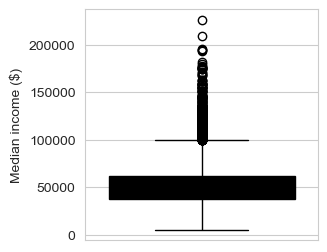

In [493]:
plt.figure(figsize=(3,3))

sns.boxplot(data=df, y='median_income', color='k')

plt.ylabel('Median income ($)')

plt.show()

Median income three quantile range is around 50,000 with outliers going up to nearly 300,000, idicating a large spread in income levels across the schools.

## Summary

1.  The numerical predictors are related to `average_act`. The relationships appear roughly linear.

2.  The numerical predictors are correlated with each other, suggesting that not all predictors will be necessary.

3.  Some variables have skewed distributions, suggesting that transformations of input variables might be useful.

4. There are outliers in `rate_unemployment`, `percent_college`, `percent_married` and `median_income`. None of these are obviously incorrect values; they likely reflect skewed distributions. We may consider applying something like a log transformation to these predictors as we explore different models.

5. The relationships are similar across charter and non-charter schools, but might be significantly different.

# Modeling

In this section, we will build predictive models to understand the impact of socioeconomic factors on student performance and analyze if we can predict average ACT/SAT scores based on these factors. We will start with a full multiple linear regression model using all predictors, then refine the model by reducing number of predictors to those that are statistically significant and evaulate if socioeconomic factors alone can predict ACT/SAT scores.

### Multiple linear regression

In this section, we will evaluate significance of our factors in predicting average ACT/SAT scores using a multiple linear regression model.

In [494]:
model = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_married + median_income + percent_lunch',
    data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     2438.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:51:59   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.667e+04
Df Residuals:                    7221   BIC:                         2.671e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6934      0.13

From above model summary, we can see that R-squared is 0.62, indicating that about 62.8% of the variance in average ACT scores can be explained by the socioeconomic factors in the model. We can also observe that percent of free lunch, rate of unempployment,  and percent of college  are statistically significant predictors (p < 0.05), while rate of median incomplete and percent of married are not statistically significant (p > 0.05). 

##### Use a residual plot for graphical assessment of model fit

In [495]:
y_hat = model.predict()

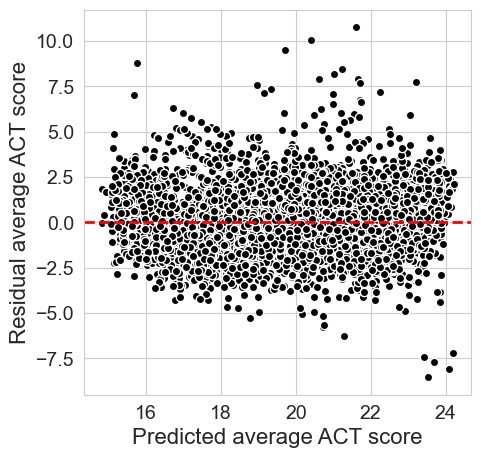

In [496]:
plt.figure(figsize=(5, 5))

plt.plot(y_hat, model.resid, 'ko', mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted average ACT score', fontsize=16)
plt.ylabel('Residual average ACT score', fontsize=16)

plt.tick_params(labelsize=14)

plt.show()

Based on the residual plot, we can see that the residuals are randomly scattered around zero, indicating that the linear regression model is appropriate for this data.

##### Evaluate model performance using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) 

We will look into the mean absolute error (MAE) to evaluate model performance for predicting ACT/SAT scores.

In [497]:
mean_absolute_error(df['average_act'], model.predict())

1.1452831432204562

Mean Absolute Error (MAE) means that on average, our model's predictions are off by about 1.15 points in scale of 1-35, which is reasonably good result for this type of data. 

Then we look into the root mean squared error (RMSE) to evaluate performance of the model with higher penalty for larger errors.

In [498]:
np.sqrt(mean_squared_error(df['average_act'], model.predict()))

np.float64(1.529911994728842)

Root Mean Squared Error (RMSE) is 1.53 points, which shows that there are some larger errors in the predictions, but overall the model performs reasonably well.

#### Predicitive model analysis with reduced number of predictors

Based on the previous model report, we can reduce the number of predictors to percent of free lunch, rate of unempployment,  and percent of college and evaluate performance.

In [499]:
model_reduced = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch',
    data=df).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     4063.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:52:00   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.666e+04
Df Residuals:                    7223   BIC:                         2.669e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6388      0.10

#### Summary

1. The multiple linear regression model with our socioeconomic predictors can predict ACT scores with an average error of roughly 1 point using these predictors.

2. The residual plot suggests that there will be limited improvement from adding transformations of these predictors.

3. Not all predictors have significant coefficients.

4. Adding predictors to the model may improve the performance.

### Fit a reduced model with the significant predictors

In [500]:
model_reduced = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch',
    data=df).fit()
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     4063.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:52:00   Log-Likelihood:                -13328.
No. Observations:                7227   AIC:                         2.666e+04
Df Residuals:                    7223   BIC:                         2.669e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6388      0.10

After reducing the model to only statistically significant predictors, we can see that our R-squared value is 0.628, which is the same as the previous model.


##### Evaluate model performance using Mean Absolute Error (MAE)

In [501]:
mean_absolute_error(df['average_act'], model_reduced.predict())

1.1454113287111085

Mean Absolute Error (MAE) is very close to previous model with all predictors. Means that reducing the number of predictors did not significantly impact model performance.

### Additional predictor analysis

I have selected instructional expenditures per student as an additional predictor to evaluate if it improves model performance. This variable represents the average amount of money spent per student by the school district, which instead of just wealth of students' families, may better capture the resources available to students.

In [502]:
df['instr_expenditures_per_student'].describe()

count     7227.000000
mean      6967.274699
std       1994.848952
min        738.013699
25%       5632.701143
50%       6326.223876
75%       7604.585818
max      19782.685124
Name: instr_expenditures_per_student, dtype: float64

We can see that there are outliers, but in general the distribution is reasonablele.

In [503]:
#### Regression analysis (original instructional expenditures per student)

We will start with plotting regression plot to visualize the relationship between instructional expenditures per student and average ACT/SAT scores.

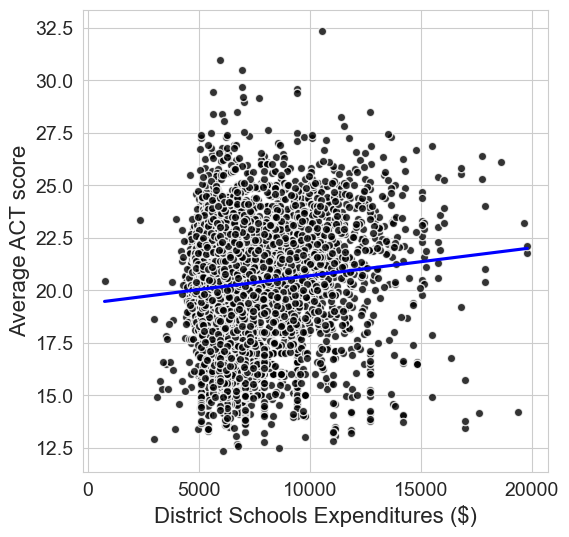

In [504]:
plt.figure(figsize=(6, 6))

sns.regplot(data=df,
            x='instr_expenditures_per_student',
            y='average_act',
            color='blue',
            ci=False,
            scatter_kws={'color': 'black', 'edgecolors': 'white', 'linewidths': 1})

# Add axis labels
plt.xlabel('District Schools Expenditures ($)', fontsize=16)
plt.ylabel('Average ACT score', fontsize=16)

# Increase the fontsize of the tick labels
plt.tick_params(labelsize=14)

plt.show()

The regression plot shows slightly positive relationship between instructional expenditures per student and average ACT/SAT scores. There data points are scattered, but linear regression is a reasonable fit for this variable.

#### Model performance evaluation with instructional expenditures per student

We will add log instructional expenditures per student to our previous reduced model and evaluate if it improves model performance.


In [514]:
model_with_expenditures = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch  + total_expenditures_per_student',
    data=df
).fit()

print(model_with_expenditures.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     2795.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:18:14   Log-Likelihood:                -12556.
No. Observations:                6914   AIC:                         2.512e+04
Df Residuals:                    6909   BIC:                         2.516e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

New model shows that R-squared remained the same. Added instr_expenditures_per_student is above 0.05 significance level, indicating that adding instructional expenditures per student does not significantly improve the model's ability to explain the variance in average ACT/SAT scores.

Evaluate model performance using Mean Absolute Error (MAE)


In [515]:
mean_absolute_error(df['average_act'], model_reduced.predict())

1.1454113287111085

In terms of model performance, adding log transformed instructional expenditures per student did not make any improvement. The MAE remained nearly the same at 1.15 points, indicating that including this additional predictor did not enhance the model's predictive accuracy.

Now we will move to scalling our predictors to normalize their values and distribution, which can let us compare their individual predictive strength.

### Scaling

Scaling predictor variables to have mean 0 and standard deviation 1 allows us to compare the relative importance of each predictor in the regression model.

In [516]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_lunch','total_expenditures_per_student']
scaled_columns = [var + '_normalized' for var in predictor_variables]

# Initialize the scaler
scaler = StandardScaler().fit(df[predictor_variables])

# Add normalized columns to dataframe
df[scaled_columns] = scaler.transform(df[predictor_variables])

df[scaled_columns].agg(['mean', 'std']).round(3)

,rate_unemployment_normalized,percent_college_normalized,percent_lunch_normalized,total_expenditures_per_student_normalized
mean,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0


All predictor variables have been successfully scaled to have mean 0 and standard deviation 1.

##### Fit the multiple linear regression model with the normalized predictors

In [517]:
model_normalized = smf.ols(
    formula='average_act ~ rate_unemployment_normalized + percent_college_normalized + percent_lunch_normalized + total_expenditures_per_student_normalized',
    data=df).fit()
print(model_normalized.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.618
Method:                 Least Squares   F-statistic:                     2795.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:19:09   Log-Likelihood:                -12556.
No. Observations:                6914   AIC:                         2.512e+04
Df Residuals:                    6909   BIC:                         2.516e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

All predictors p-value is under 0.05, indicating that they are statistically significant in predicting average ACT/SAT scores. The R-squared went slightly down from 0.628 to 0.622.

##### Compare the accuracy between the original and normalized models

In [509]:
mae_normalized = mean_absolute_error(df['average_act'], model_normalized.predict())
mae = mean_absolute_error(df['average_act'], model_with_expenditures.predict())

r2_normalized = model_normalized.rsquared
r2 = model_with_expenditures.rsquared

pd.DataFrame({'Mean Absolute Error': [mae_normalized, mae],
              'R-squared': [r2_normalized, r2]},
              index=['normalized model', 'regular model']).round(4)

,Mean Absolute Error,R-squared
normalized model,1.1457,0.628
regular model,1.1457,0.628


## Summary

1. The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis.

# Conclusion

The analysis shows that college entrance test scores (ACT and SAT) are related to socioeconomic variables.

In particular, using only the percent of students at a school receiving free or reduced price lunch, we can predict ACT scores to within a single point, on average.

The percent of students at a school receiving free or reduced price lunch was the strongest predictor in this analysis. It was also the only variable measured for students at the school, rather than for the neighborhood. It is an open question how important the other predictors would be if they were measured for the students at the school, rather than for the neighborhood.

